In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path
pd.set_option("display.max_columns", None) 
pd.set_option("display.max_rows", 100)

In [2]:
# Task 3: Define Folder Paths
DATA_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
REPORTS_DIR = Path("../reports")
FIGURES_DIR = Path("../figures")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

for file in DATA_DIR.glob("*.csv"):
    print(file.name)

olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [3]:
# Task 4: Load Required Tables
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
category_translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

tables = {
    "orders": orders,
    "customers": customers,
    "reviews": reviews,
    "payments": payments,
    "order_items": order_items,
    "products": products,
    "category_translation": category_translation
}
for name, df in tables.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

orders: 99441 rows, 8 columns
customers: 99441 rows, 5 columns
reviews: 99224 rows, 7 columns
payments: 103886 rows, 5 columns
order_items: 112650 rows, 7 columns
products: 32951 rows, 9 columns
category_translation: 71 rows, 2 columns


In [4]:
# Task 7: Convert Date Columns
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

In [5]:
# Task 8: Create Date-Based Features
orders["order_year"] = orders["order_purchase_timestamp"].dt.year
orders["order_month"] = orders["order_purchase_timestamp"].dt.month
orders["order_day"] = orders["order_purchase_timestamp"].dt.day
orders["order_day_of_week"] = orders["order_purchase_timestamp"].dt.dayofweek
orders["order_hour"] = orders["order_purchase_timestamp"].dt.hour


In [6]:
# Task 9: Create Delivery-Based Features
orders["delivery_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

orders["estimated_delivery_days"] = (
    orders["order_estimated_delivery_date"] - orders["order_purchase_timestamp"]
).dt.days

orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.days

orders["is_late_delivery"] = np.where(orders["delivery_delay_days"] > 0, 1, 0)

In [7]:
# Task 11: Aggregate Payments Data
payment_features = payments.groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    max_payment_installments=("payment_installments", "max"),
    payment_types_count=("payment_type", "nunique")
).reset_index()

In [8]:
# Task 12: Add Dominant Payment Type
dominant_payment_type = payments.groupby("order_id")["payment_type"].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
).reset_index()

dominant_payment_type = dominant_payment_type.rename(
    columns={"payment_type": "dominant_payment_type"}
)

payment_features = payment_features.merge(
    dominant_payment_type,
    on="order_id",
    how="left"
)

In [9]:
# Task 13: Aggregate Order Items Data
item_features = order_items.groupby("order_id").agg(
    total_items=("order_item_id", "count"),
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum"),
    unique_products=("product_id", "nunique"),
    unique_sellers=("seller_id", "nunique")
).reset_index()

In [10]:
# Task 14: Add Product Category Information
items_products = order_items.merge(products, on="product_id", how="left")
items_products = items_products.merge(category_translation, on="product_category_name", how="left")


In [11]:
# Task 15: Create Main Product Category Per Order
order_category = items_products.groupby("order_id").agg(
    main_product_category=(
        "product_category_name_english",
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )
).reset_index()

In [12]:
# Task 16: Prepare Review Features
review_features = reviews.groupby("order_id").agg(
    review_score=("review_score", "mean"),
    review_comment_count=("review_comment_message", lambda x: x.notnull().sum()),
    has_review_comment=("review_comment_message", lambda x: int(x.notnull().any()))
).reset_index()

In [13]:
# Task 17: Create the Analytical Base Table
abt = orders.merge(customers, on="customer_id", how="left")
abt = abt.merge(review_features, on="order_id", how="left")
abt = abt.merge(payment_features, on="order_id", how="left")
abt = abt.merge(item_features, on="order_id", how="left")
abt = abt.merge(order_category, on="order_id", how="left")

In [14]:
# Task 18: Create Low Review Target Variable
abt["is_low_review"] = np.where(abt["review_score"] <= 2, 1, 0)

In [15]:
# Task 19: Select Final Columns
selected_columns = [
    "order_id", "customer_id", "customer_unique_id", "customer_city", "customer_state",
    "order_status", "order_year", "order_month", "order_day", "order_day_of_week",
    "order_hour", "delivery_days", "estimated_delivery_days", "delivery_delay_days",
    "is_late_delivery", "review_score", "is_low_review", "review_comment_count",
    "has_review_comment", "total_payment_value", "max_payment_installments",
    "payment_types_count", "dominant_payment_type", "total_items", "total_price",
    "total_freight", "unique_products", "unique_sellers", "main_product_category"
]

abt = abt[selected_columns]

In [17]:
# Task 19: Select Final Columns
selected_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "customer_city",
    "customer_state",
    "order_status",
    "order_year",
    "order_month",
    "order_day",
    "order_day_of_week",
    "order_hour",
    "delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "is_late_delivery",
    "review_score",
    "is_low_review",
    "review_comment_count",
    "has_review_comment",
    "total_payment_value",
    "max_payment_installments",
    "payment_types_count",
    "dominant_payment_type",
    "total_items",
    "total_price",
    "total_freight",
    "unique_products",
    "unique_sellers",
    "main_product_category"
]

abt = abt[selected_columns]

In [18]:
# Task 20: Inspect Final ABT
print("Shape:", abt.shape)
print("\nData Types:")
print(abt.info())
print("\nMissing Values:")
print(abt.isnull().sum().sort_values(ascending=False))
print("\nDuplicate Orders:", abt["order_id"].duplicated().sum())

Shape: (99441, 29)

Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  99441 non-null  str    
 1   customer_id               99441 non-null  str    
 2   customer_unique_id        99441 non-null  str    
 3   customer_city             99441 non-null  str    
 4   customer_state            99441 non-null  str    
 5   order_status              99441 non-null  str    
 6   order_year                99441 non-null  int32  
 7   order_month               99441 non-null  int32  
 8   order_day                 99441 non-null  int32  
 9   order_day_of_week         99441 non-null  int32  
 10  order_hour                99441 non-null  int32  
 11  delivery_days             96476 non-null  float64
 12  estimated_delivery_days   99441 non-null  int64  
 13  delivery_delay_days       96476 non-null

In [20]:
# Task 21: Create ABT Summary Report
abt_summary = pd.DataFrame({
    "column": abt.columns,
    "data_type": abt.dtypes.astype(str).values,
    "missing_count": abt.isnull().sum().values,
    "missing_percent": (abt.isnull().sum().values / len(abt)) * 100,
    "unique_values": [abt[col].nunique() for col in abt.columns]
})
abt_summary.to_csv(REPORTS_DIR / "lab02_abt_summary.csv", index=False)

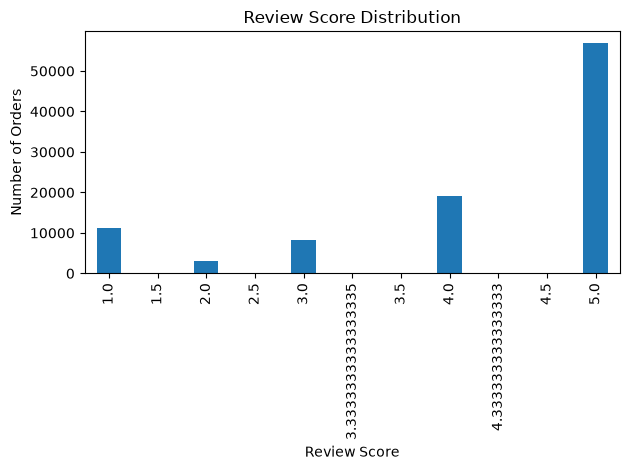

In [21]:
# Task 22: Visualize Key Features

## Review Score Distribution
abt["review_score"].value_counts().sort_index().plot(kind="bar")
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab02_review_score_distribution.png")
plt.show()

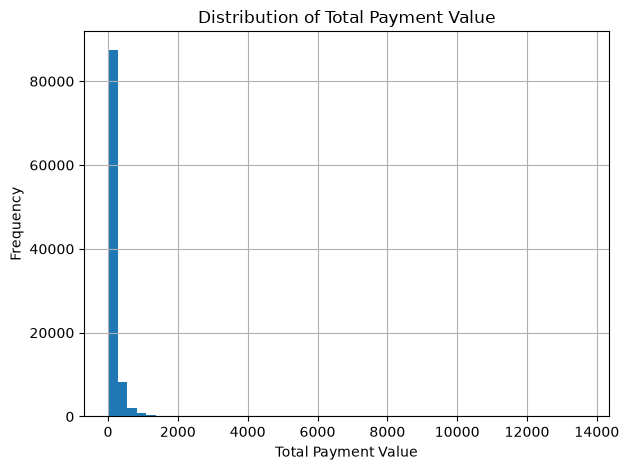

In [22]:
## Payment Value Distribution
abt["total_payment_value"].hist(bins=50)
plt.title("Distribution of Total Payment Value")
plt.xlabel("Total Payment Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab02_payment_value_distribution.png")
plt.show()

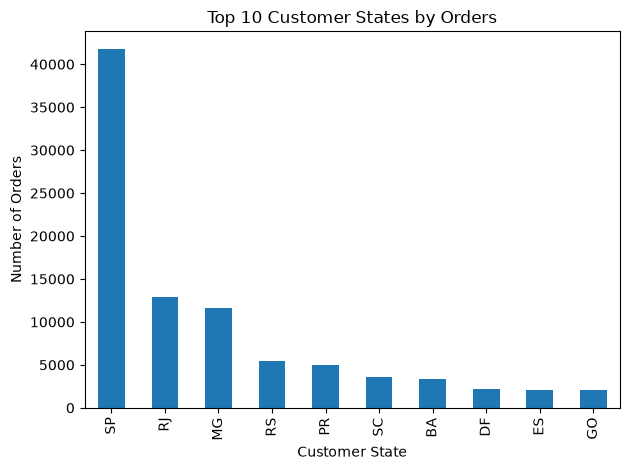

In [23]:
## Top Customer States
abt["customer_state"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Customer States by Orders")
plt.xlabel("Customer State")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lab02_top_customer_states.png")
plt.show()

In [24]:
# Task 23: Save Final Processed Dataset
abt.to_csv(PROCESSED_DIR / "olist_orders_abt.csv", index=False)

In [25]:
(PROCESSED_DIR / "olist_orders_abt.csv").exists()

True

In [26]:
abt_check = pd.read_csv(PROCESSED_DIR / "olist_orders_abt.csv")
abt_check.head()

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_year,order_month,order_day,order_day_of_week,order_hour,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery,review_score,is_low_review,review_comment_count,has_review_comment,total_payment_value,max_payment_installments,payment_types_count,dominant_payment_type,total_items,total_price,total_freight,unique_products,unique_sellers,main_product_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017,10,2,0,10,8.0,15,-8.0,0,4.0,0,1.0,1.0,38.71,1.0,2.0,voucher,1.0,29.99,8.72,1.0,1.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018,7,24,1,20,13.0,19,-6.0,0,4.0,0,1.0,1.0,141.46,1.0,1.0,boleto,1.0,118.70,22.76,1.0,1.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018,8,8,2,8,9.0,26,-18.0,0,5.0,0,0.0,0.0,179.12,3.0,1.0,credit_card,1.0,159.90,19.22,1.0,1.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,delivered,2017,11,18,5,19,13.0,26,-13.0,0,5.0,0,1.0,1.0,72.20,1.0,1.0,credit_card,1.0,45.00,27.20,1.0,1.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,delivered,2018,2,13,1,21,2.0,12,-10.0,0,5.0,0,0.0,0.0,28.62,1.0,1.0,credit_card,1.0,19.90,8.72,1.0,1.0,stationery


In [27]:
# Task 46.1: Monthly Order Count
monthly_orders = abt.groupby(["order_year", "order_month"]).agg(
    order_count=("order_id", "count"),
    total_revenue=("total_payment_value", "sum")
).reset_index()

print(monthly_orders.head())

   order_year  order_month  order_count  total_revenue
0        2016            9            4         252.24
1        2016           10          324       59090.48
2        2016           12            1          19.62
3        2017            1          800      138488.04
4        2017            2         1780      291908.01


In [28]:
# Task 46.2: Average Review Score by Customer State
avg_review_by_state = abt.groupby("customer_state").agg(
    avg_review_score=("review_score", "mean"),
    order_count=("order_id", "count")
).reset_index()

print(
    avg_review_by_state.sort_values(
        by="avg_review_score",
        ascending=False
    ).head()
)

   customer_state  avg_review_score  order_count
2              AM          4.205479          148
3              AP          4.194030           68
17             PR          4.181112         5045
25             SP          4.174126        41746
10             MG          4.135754        11635


In [29]:
# Task 46.3: Late Delivery Rate by Product Category
late_delivery_by_category = abt.groupby("main_product_category").agg(
    late_delivery_rate=("is_late_delivery", "mean"),
    order_count=("order_id", "count")
).reset_index()

print(
    late_delivery_by_category.sort_values(
        by="late_delivery_rate",
        ascending=False
    ).head()
)

                main_product_category  late_delivery_rate  order_count
41  furniture_mattress_and_upholstery            0.131579           38
46                     home_comfort_2            0.130435           23
4                               audio            0.117143          350
47                       home_confort            0.099715          351
33            fashion_underwear_beach            0.090909          121
